# 付録 フーリエ変換と相関処理

## 概要
フーリエ変換の基本原理と相関処理の理解を目的とした演習です。
時間領域の複合信号を周波数領域に変換し、さらに時間領域と周波数領域での相関処理を比較します。

## 処理内容

| 項目 | 情報 |
| ---- | ---- |
| サンプリング周波数 | 2000 Hz |
| 信号長 | 0.1 秒 |
| 使用周波数成分 | 30Hz, 60Hz, 120Hz |
| 出力ディレクトリ | /work/outputs/fourier/ |

In [1]:
# 必要なライブラリのインポート
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 警告メッセージを非表示
warnings.filterwarnings('ignore')

In [2]:
# 出力先のパス設定
PATH_OUTPUT = '/work/outputs/fourier/'

# 信号生成パラメータ
SAMPLING_FREQ = 2000        # サンプリング周波数 (Hz)
DURATION = 0.1              # 信号の長さ (秒)
FREQ_1 = 30                 # 第1成分の周波数 (Hz)
FREQ_2 = 60                 # 第2成分の周波数 (Hz)
FREQ_3 = 120                # 第3成分の周波数 (Hz)

# 時間軸の生成
t = np.linspace(0, DURATION, int(SAMPLING_FREQ * DURATION))

# 出力ディレクトリが存在しない場合は作成
os.makedirs(PATH_OUTPUT, exist_ok=True)

# 単純な正弦波信号の生成

単純信号の生成
サンプル数: 200
生成周波数: 30 Hz, 60 Hz, 120 Hz


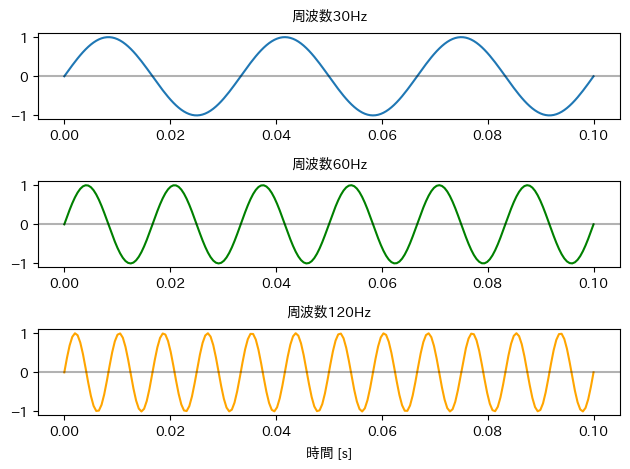

In [3]:
# 単純な信号の作成
signal_f30 = np.sin(2*np.pi*FREQ_1*t)
signal_f60 = np.sin(2*np.pi*FREQ_2*t)
signal_f120 = np.sin(2*np.pi*FREQ_3*t)

print('=' * 60)
print('単純信号の生成')
print('=' * 60)
print(f'サンプル数: {len(t)}')
print(f'生成周波数: {FREQ_1} Hz, {FREQ_2} Hz, {FREQ_3} Hz')
print('=' * 60)

# 可視化
plt.subplot(3, 1, 1)
plt.title('周波数30Hz', pad=10, fontsize=10)
plt.plot(t, signal_f30)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.subplot(3, 1, 2)
plt.title('周波数60Hz', pad=10, fontsize=10)
plt.plot(t, signal_f60, color='green')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.subplot(3, 1, 3)
plt.title('周波数120Hz', pad=10, fontsize=10)
plt.plot(t, signal_f120, color='orange')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('時間 [s]', labelpad=5)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'figure2.png'), dpi=150, bbox_inches='tight')
plt.show()

# 複合信号の生成

複合信号の生成
信号長: 200
振幅範囲: -2.23 - 2.23


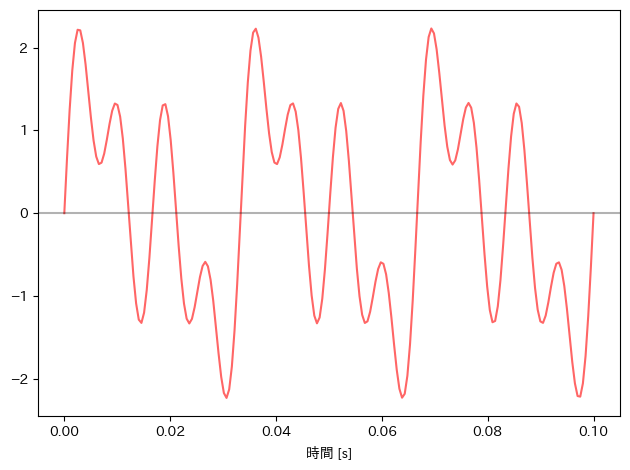

In [4]:
# 複合信号の生成
signal_sum = signal_f30 + signal_f60 + signal_f120

print('=' * 60)
print('複合信号の生成')
print('=' * 60)
print(f'信号長: {len(signal_sum)}')
print(f'振幅範囲: {np.min(signal_sum):.2f} - {np.max(signal_sum):.2f}')
print('=' * 60)

# 可視化
plt.plot(t, signal_sum, color='red', alpha=0.6)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('時間 [s]', labelpad=5)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'figure3.png'), dpi=150, bbox_inches='tight')
plt.show()

# フーリエ変換による周波数解析

フーリエ変換結果
FFTサンプル数: 200
周波数分解能: 10.00 Hz


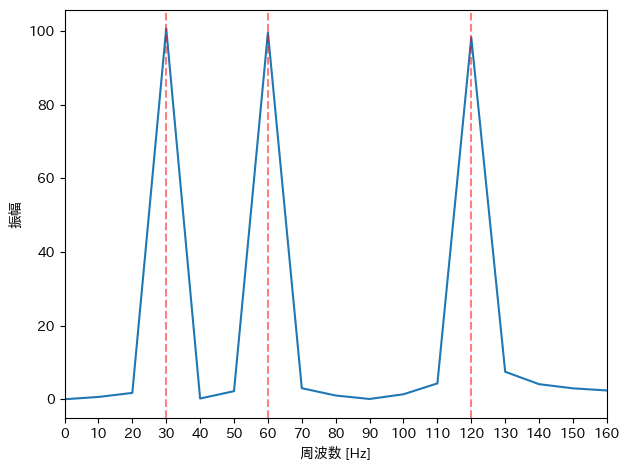

In [5]:
# 合成信号にフーリエ変換を適用
n = len(t)
fft_result = np.fft.fft(signal_sum)
fft_freq = np.fft.fftfreq(n, 1/SAMPLING_FREQ)

print('=' * 60)
print('フーリエ変換結果')
print('=' * 60)
print(f'FFTサンプル数: {n}')
print(f'周波数分解能: {fft_freq[1]:.2f} Hz')
print('=' * 60)

# 可視化
amplitude = np.abs(fft_result)

plt.plot(fft_freq[:n//2], amplitude[:n//2])
plt.axvline(x=30, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=60, color='r', linestyle='--', alpha=0.5) 
plt.axvline(x=120, color='r', linestyle='--', alpha=0.5)
plt.xlabel('周波数 [Hz]')
plt.ylabel('振幅')
plt.xticks(np.arange(0, 161, 10))
plt.xlim(0, 160)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'figure4.png'), dpi=150, bbox_inches='tight')
plt.show()

# 時間領域と周波数領域での相関処理

相関処理結果
相関配列長: 399
ラグ範囲: -99.50 - 99.50 ms


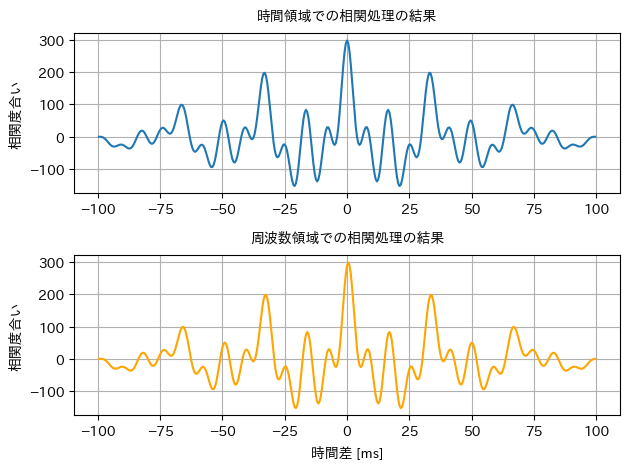

In [6]:
# 同じ合成信号を生成（コピー）
signal_copy = signal_sum

# 時間領域での相関処理
correlation_time = np.correlate(signal_sum, signal_copy, mode='full')

# 周波数領域での相関処理
fft1 = np.fft.fft(signal_sum, n=2*n-1)
fft2 = np.fft.fft(signal_copy, n=2*n-1)
fft_product = fft1 * np.conj(fft2)
correlation_freq = np.fft.ifftshift(np.fft.ifft(fft_product))
correlation_freq = np.real(correlation_freq)

# ラグの計算
lags = np.arange(-(len(signal_sum) - 1), len(signal_sum))
lag_times = lags / SAMPLING_FREQ

print('=' * 60)
print('相関処理結果')
print('=' * 60)
print(f'相関配列長: {len(correlation_time)}')
print(f'ラグ範囲: {lag_times[0]*1000:.2f} - {lag_times[-1]*1000:.2f} ms')
print('=' * 60)

# 可視化
plt.subplot(2, 1, 1)
plt.plot(lag_times * 1000, correlation_time)
plt.title('時間領域での相関処理の結果', pad=10, fontsize=10)
plt.ylabel('相関度合い')
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(lag_times * 1000, correlation_freq, color='orange')
plt.title('周波数領域での相関処理の結果', pad=10, fontsize=10)
plt.xlabel('時間差 [ms]', labelpad=5)
plt.ylabel('相関度合い')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'figure5.png'), dpi=150, bbox_inches='tight')
plt.show()